### Importação de Bibliotecas

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parâmetros e Sinais ---
L = 6  # Comprimento do sinal x[n]
N_a = 6  # N para convolução circular no item 2(a)

# Sequência x[n] (Assumindo uma sequência simples de comprimento 6, como {1, 2, 3, 4, 5, 6})
# O enunciado não fornece os valores, apenas o comprimento L=6.
x = np.array([6, 5, 4, 3, 2, 1])

# Resposta ao Impulso h[n]
# h[n] = delta[n] + delta[n-1] + delta[n-2]
h = np.array([1, 1, 1])
P = len(h) # Comprimento de h[n] = 3



# Questão 2

## a) Convolução Circular


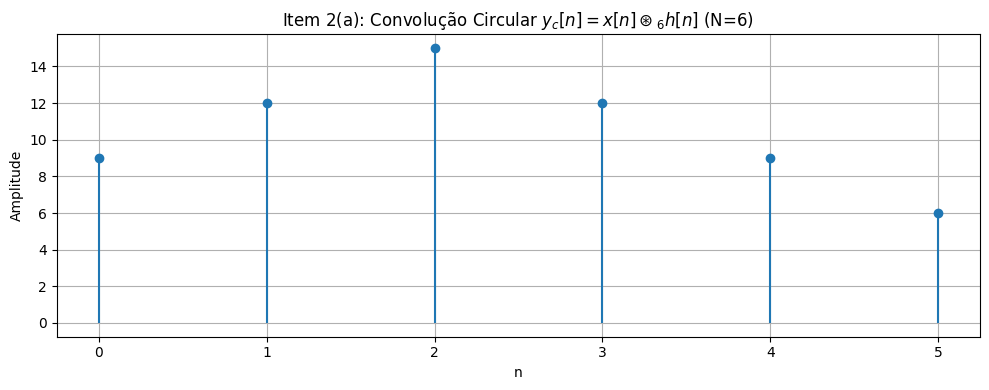

Item 2(a) Convolução Circular (N=6): [ 9. 12. 15. 12.  9.  6.]


In [6]:
# --- Item 2(a): Convolução Circular com N=6 ---

# 1. Cálculo da DFT dos sinais (com N=6 pontos)
X_k_a = np.fft.fft(x, N_a)
H_k_a = np.fft.fft(h, N_a)

# 2. Multiplicação dos espectros (Convolução Circular no tempo)
Y_k_a = X_k_a * H_k_a

# 3. IDFT para obter o resultado da convolução circular y_c[n]
y_c_a = np.fft.ifft(Y_k_a).real

# 4. Plotagem
n_a = np.arange(N_a)
plt.figure(figsize=(10, 4))
plt.stem(n_a, y_c_a, basefmt=" ")
plt.title(f'Item 2(a): Convolução Circular $y_c[n] = x[n] \\circledast_6 h[n]$ (N={N_a})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.tight_layout()
plt.savefig('2a_circular_convolution.png')
plt.show()
plt.close()

print(f"Item 2(a) Convolução Circular (N={N_a}): {y_c_a}")
#print(f"Gráfico salvo em 2a_circular_convolution.png")



## b) Convolução Linear e Circular Equivalente


Item 2(b) N mínimo para equivalência: N_min = L + P - 1 = 6 + 3 - 1 = 8


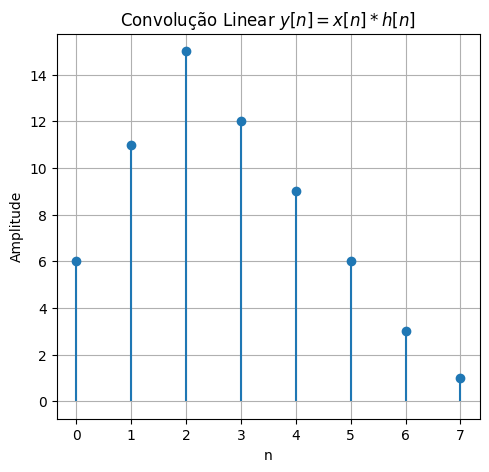

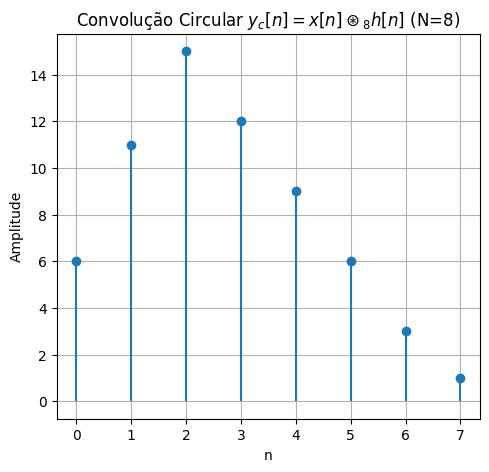

<Figure size 640x480 with 0 Axes>

Item 2(b) Convolução Linear: [ 6 11 15 12  9  6  3  1]
Item 2(b) Convolução Circular (N=8): [ 6. 11. 15. 12.  9.  6.  3.  1.]
Verificação: As convoluções linear e circular com N_min são iguais.


In [7]:
# --- Item 2(b): Convolução Linear e Circular Equivalente ---

# 1. Determinação do N mínimo para equivalência
# N_min = L + P - 1
N_min = L + P - 1
print(f"\nItem 2(b) N mínimo para equivalência: N_min = L + P - 1 = {L} + {P} - 1 = {N_min}")

# 2. Convolução Linear (Referência)
y_linear = np.convolve(x, h)
n_linear = np.arange(len(y_linear))

# 3. Convolução Circular com N_min
# Estender x[n] e h[n] com zero-padding para N_min
X_k_b = np.fft.fft(x, N_min)
H_k_b = np.fft.fft(h, N_min)

# Multiplicação dos espectros
Y_k_b = X_k_b * H_k_b

# IDFT para obter o resultado da convolução circular y_c[n]
y_c_b = np.fft.ifft(Y_k_b).real

# 4. Plotagem
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.stem(n_linear, y_linear, basefmt=" ")
plt.title(f'Convolução Linear $y[n] = x[n] * h[n]$')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
plt.stem(np.arange(N_min), y_c_b, basefmt=" ")
plt.title(f'Convolução Circular $y_c[n] = x[n] \\circledast_{{{N_min}}} h[n]$ (N={N_min})')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

plt.tight_layout()
plt.savefig('2b_linear_vs_circular.png')
plt.show()
plt.close()

print(f"Item 2(b) Convolução Linear: {y_linear}")
print(f"Item 2(b) Convolução Circular (N={N_min}): {y_c_b}")
#print(f"Gráfico salvo em 2b_linear_vs_circular.png")

# Verificação da igualdade (para o relatório)
if np.allclose(y_linear, y_c_b):
    print("Verificação: As convoluções linear e circular com N_min são iguais.")
else:
    print("Verificação: ERRO! As convoluções linear e circular com N_min NÃO são iguais.")